In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('bank_transactions_data_2.csv')


In [2]:
df.shape

(2512, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [4]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [5]:
df.tail()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22
2511,TX002512,AC00009,243.08,2023-02-14 16:21:23,Credit,Jacksonville,D000215,59.127.135.25,M041,Online,24,Student,93,1,131.25,2024-11-04 08:07:49


In [6]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [7]:
# data cleaning

In [10]:
# convert dates
df['TransactionDate']=pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

#Drop duplicates
df.drop_duplicates(inplace=True)

#handle missing values
df.fillna({'CustomerOccupation':'Unknown'},inplace=True)

#Feature Engineering: time since last transction
df['DaysSinceLastTxn'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.days

In [11]:
#Feature Engineering for Risk Signals

In [2]:
#Flag unusally high transction amounts(z-score based)
df['AmountZScore'] = (df['TransactionAmount'] - df['TransactionAmount'].mean()) / df['TransactionAmount'].std()

#Flag high login attempts(possible account compromise attempts)
df['HighLoginAttempts'] = df['LoginAttempts'] > 3

# Flag odd transaction duration (very short = automated/bot-like)
df['ShortDuration'] = df['TransactionDuration'] < df['TransactionDuration'].quantile(0.05)

# Flag transactions that drain most of the balance
df['HighAmountVsBalance'] = df['TransactionAmount'] / (df['AccountBalance']+1) > 0.7

In [3]:
# Composite Risk Score

In [4]:
risk_weights = {
    'AmountZScore':        lambda x: np.where(x.abs() > 2, 25, 0),
    'HighLoginAttempts':   lambda x: np.where(x, 20, 0),
    'ShortDuration':       lambda x: np.where(x, 15, 0),
    'HighAmountVsBalance': lambda x: np.where(x, 20, 0),
}

df['RiskScore'] = sum(func(df[col]) for col, func in risk_weights.items())

# Categorize risk (max possible score is now 80)
def risk_level(score):
    if score >= 45: return 'High'
    elif score >= 20: return 'Medium'
    else: return 'Low'

df['RiskLevel'] = df['RiskScore'].apply(risk_level)

print(df['RiskLevel'].value_counts())
print((df['RiskLevel'].value_counts(normalize=True) * 100).round(1))

RiskLevel
Low       2212
Medium     259
High        41
Name: count, dtype: int64
RiskLevel
Low       88.1
Medium    10.3
High       1.6
Name: proportion, dtype: float64


In [20]:
#Exploratory Analysis

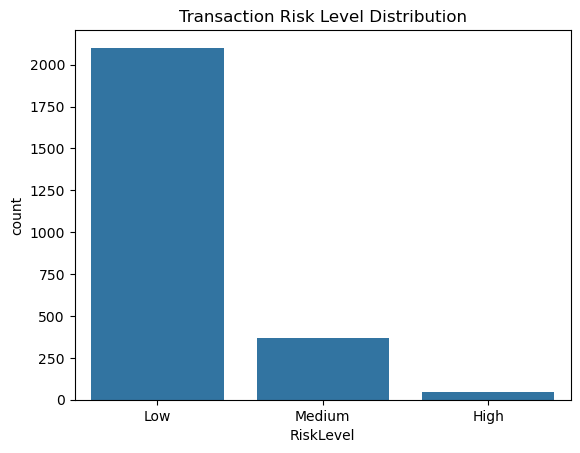

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#Risk Distribution
sns.countplot(data=df, x='RiskLevel', order=['Low','Medium','High'])
plt.title('Transaction Risk Level Distribution')
plt.show()

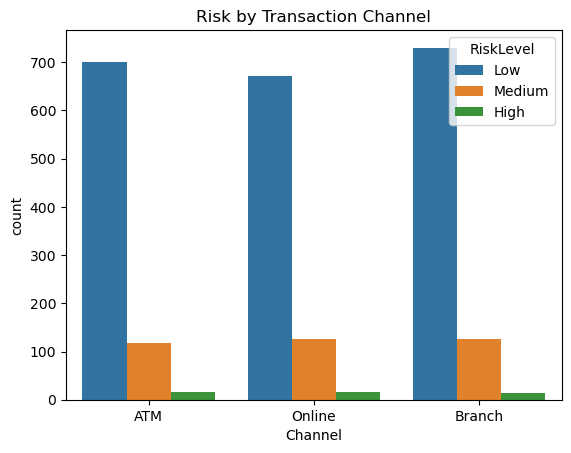

In [22]:
#Risk by channel
sns.countplot(data=df, x='Channel', hue='RiskLevel')
plt.title('Risk by Transaction Channel')
plt.show()

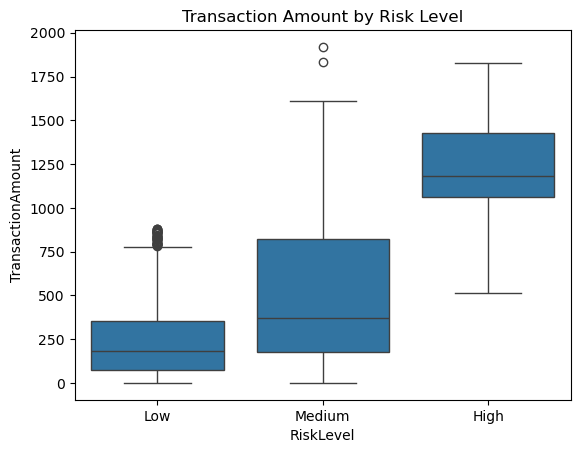

In [23]:
# Amount distribution by risk
sns.boxplot(data=df, x='RiskLevel', y='TransactionAmount')
plt.title('Transaction Amount by Risk Level')
plt.show()

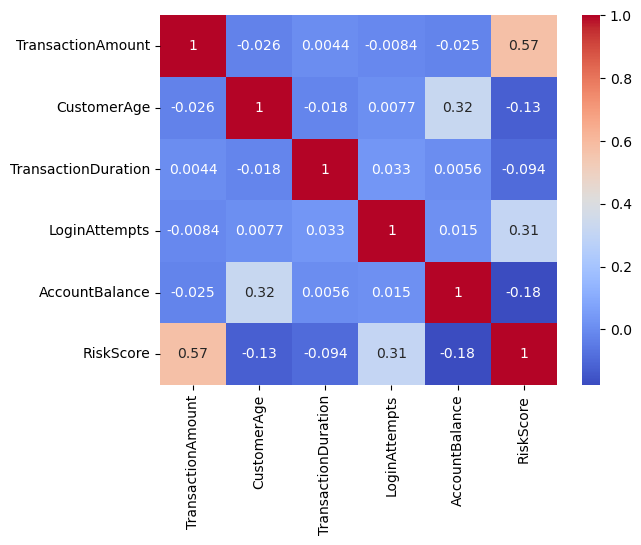

In [24]:
# Correlation heatmap
numeric_cols = ['TransactionAmount','CustomerAge','TransactionDuration','LoginAttempts','AccountBalance','RiskScore']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [26]:
df.to_csv('transactions_with_risk_score.csv', index=False)